In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
from sklearn.datasets import load_diabetes

data=load_diabetes()

In [15]:
print(data.DESCR)


.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [16]:
X=data.data
y=data.target

In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=45)

In [18]:
from sklearn.linear_model import LinearRegression
L=LinearRegression()

In [19]:
L.fit(X_train,y_train)

LinearRegression()

In [20]:
print(L.coef_)
print(L.intercept_)

[  23.45465406 -247.42747406  492.1087518   329.35876431 -970.79723039
  573.54295519  182.42162368  255.92168168  794.21609282   89.32249214]
152.13623331746496


In [21]:
y_pred=L.predict(X_test)


In [22]:
from sklearn.metrics import r2_score,mean_squared_error

print("R2 score",r2_score(y_test,y_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))

R2 score 0.5188113124539249
RMSE 48.72713760953253


In [23]:
from sklearn.linear_model import Ridge
R = Ridge(alpha=10000)

In [24]:
R.fit(X_train,y_train)

Ridge(alpha=10000)

In [26]:
print(R.coef_)
print(R.intercept_)

[ 0.02600397  0.00569999  0.07764433  0.06096237  0.02337539  0.0184614
 -0.05138155  0.05270009  0.07344326  0.05284829]
151.83304231078424


In [27]:
y_pred1=R.predict(X_test)


In [28]:
print("R2 score",r2_score(y_test,y_pred1))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred1)))

R2 score -0.00018352535703880513
RMSE 70.2510863104429


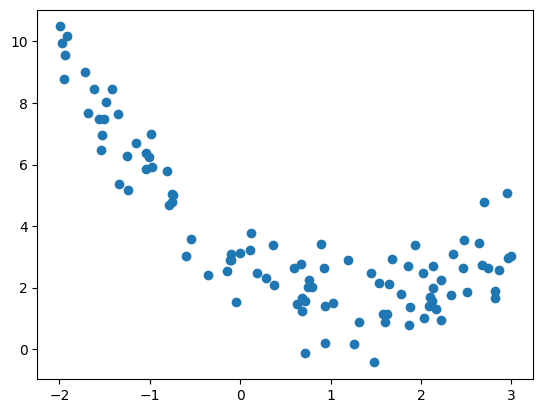

In [29]:
m = 100
x1 = 5* np.random.rand(m,1) -2
x2 = 0.7 * x1 ** 2 - 2* x1+3 +np.random.randn(m,1)

plt.scatter(x1,x2)
plt.show()

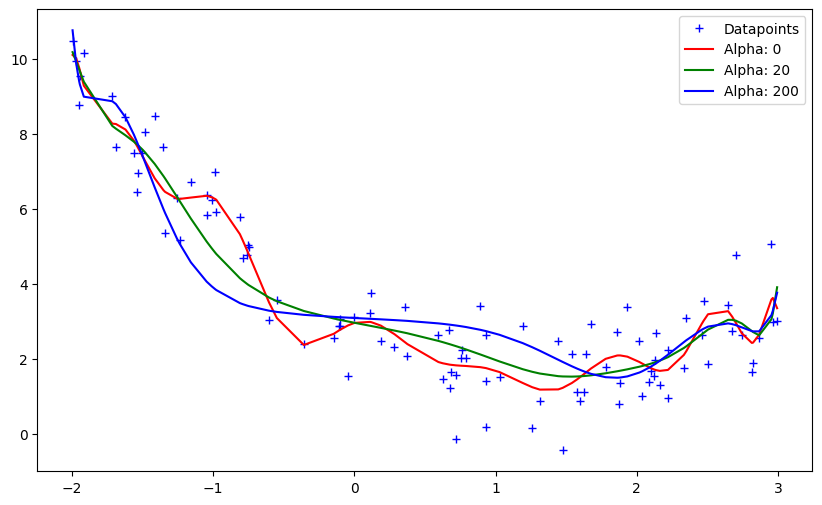

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()

Ridge Regularization Explained
Ridge Regularization, also known as L2 regularization, is a technique used in machine learning to prevent overfitting in regression models. Overfitting happens when a model learns the training data too well, including its noise and random fluctuations. This leads to poor performance on new, unseen data.

How it Works:

Ridge regularization adds a penalty term to the ordinary least squares (OLS) loss function that is used to train a linear regression model. This penalty term is proportional to the square of the magnitude of the model's coefficients.

Loss = OLS Loss + α * (sum of squared coefficients)

Where:

OLS Loss: The usual loss function for linear regression, which measures the difference between the model's predictions and the actual values.
α (alpha): The regularization parameter, which controls the strength of the penalty. A higher alpha means stronger regularization.
Sum of squared coefficients: The sum of the squares of the model's coefficients (the weights assigned to each feature).
Benefits of Ridge Regularization:

Reduces Overfitting: By penalizing large coefficients, Ridge regularization discourages the model from fitting the training data too closely. This helps to generalize better to new data.
Handles Multicollinearity: When features in the data are highly correlated (multicollinearity), it can be difficult for the model to determine the importance of each feature. Ridge regularization helps to stabilize the model's estimates in these situations.
Improves Model Stability: Small changes in the training data can lead to large changes in the model's coefficients when overfitting occurs. Ridge regularization makes the model more robust to these variations.
Choosing the Regularization Parameter (α):

The value of alpha is crucial in Ridge regularization.

α = 0: No regularization, equivalent to ordinary least squares.
α = very large: Coefficients are heavily penalized, leading to a very simple model (potentially underfitting).
The optimal value of alpha is typically found using techniques like cross-validation, where the model is evaluated on different subsets of the data to find the value that gives the best performance on unseen data.

In the code you provided, Ridge regularization is used within the get_preds_ridge function to build a polynomial regression model. The different values of alpha in the alphas list are used to demonstrate the effect of varying the regularization strength.

**Ridge Regression: Drawbacks in a Nutshell**
Doesn't eliminate features: Shrinks coefficients towards zero but keeps all predictors in the model.
Introduces bias: Trades some accuracy for improved generalization and stability.
Can reduce interpretability: Shrunken coefficients make it harder to understand feature importance.
Sensitive to feature scaling: Requires scaling features before application for optimal performance.
Not ideal for sparse solutions: Less effective when only a few features are truly relevant.